# Fase 8 — Skip-gram contra CBOW

Las siete fases anteriores entrenaron **una sola arquitectura**. Esta agrega la
otra mitad de word2vec y hace la comparación que el proyecto todavía no había
hecho: no mover un hiperparámetro, sino cambiar *cómo se plantea la tarea*.

## Diseño del experimento

`piloto_sg_5k_50_2` es el **gemelo exacto** de `piloto_5k_50_2`. Cambia una sola
llave del YAML:

```yaml
arch: "skipgram"     # <- lo único
```

| Fijo | Valor |
|---|---|
| vocabulario | el mismo `vocab.json` de 5.000 palabras del corpus completo (`vocab_from`) |
| corpus | las mismas 2M de oraciones de `muestra_2m.txt` |
| ventana | contexto 2, **fija** (no sorteada por token) en las dos |
| dim / épocas / batch / lr / negativos / semilla | 50 / 15 / 512 / 0,003 / 10 / 42 |

## La misma ventana, leída al revés

Acá está toda la diferencia. Sobre la misma oración y la misma ventana:

```
... sudán palestinos regresar hogares la ...

CBOW        [sudán palestinos hogares la]  ->  regresar      1 par por token
skip-gram   regresar -> [sudán]
            regresar -> [palestinos]                          1 par por vecino
            regresar -> [hogares]
            regresar -> [la]
```

CBOW promedia el contexto y predice el centro; skip-gram parte del centro y
predice cada vecino por separado. En el código eso es un `forward` de dos líneas
(`CBOWModel` vs `SkipGramModel`); el resto —negative sampling, loss, optimizador,
checkpoints— es literalmente el mismo.

## Cómo se compara, y cómo no

> **La loss NO se compara entre arquitecturas.** No es que una resuelva una
> versión más fácil de la misma tarea, como pasaba con el contexto en la Fase 7:
> son **tareas distintas**, sobre conjuntos de pares de tamaños distintos
> (2,77x más en skip-gram). Un número más bajo acá no significaría nada.
> `comparable_loss` en `src/compare.py` incluye `arch` justamente para que las
> dos familias no se crucen por accidente.

Lo que sí vale:

1. **La precisión en analogías**, que mide el espacio de embeddings resultante y
   no la tarea que lo produjo.
2. **McNemar sobre los mismos ítems**, bastante más sensible que comparar dos
   porcentajes con sus intervalos: ~286 ítems dan un IC de ±6 puntos, y las
   diferencias que nos interesan pueden ser más chicas que eso.
3. **La precisión desagregada por frecuencia de la palabra**, que es donde la
   teoría hace una predicción concreta: skip-gram debería rendir mejor con
   palabras poco frecuentes, porque cada par las pone solas del lado de la
   entrada en vez de diluidas en el promedio de un contexto.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np

from src.compare import collect, mcnemar
from src.config import load_config, vocab_path
from src.evaluate import load_embeddings, nearest_neighbors
from src.vocabulary import Vocabulary

plt.rcParams["figure.dpi"] = 110

CBOW, SG = "piloto_5k_50_2", "piloto_sg_5k_50_2"
PAR = [CBOW, SG]

ETIQUETA = {CBOW: "CBOW", SG: "skip-gram"}
COLOR = {CBOW: "#2a6f97", SG: "#8b3a3a"}

FILAS = {f["name"]: f for f in collect(PAR)}
CATEGORIAS = list(FILAS[CBOW]["categories"])

# El vocabulario es el mismo para las dos (vocab_from), así que alcanza con uno.
VOCAB = Vocabulary.load(vocab_path(load_config(f"configs/{CBOW}.yaml")))


def aciertos(nombre, categoria=None):
    # Resultado ítem por ítem, para las pruebas pareadas.
    return [h for cat, *_, h in FILAS[nombre]["items"]
            if categoria is None or cat == categoria]


for nombre in PAR:
    f = FILAS[nombre]
    lo, hi = f["accuracy_ci"]
    print(f"{ETIQUETA[nombre]:<10} loss {f['val_loss']:.4f} (no comparable entre filas) | "
          f"analogías {f['accuracy']:5.1%} [{lo:.1%}, {hi:.1%}] | "
          f"{f['pairs_per_epoch']:>11,} pares/época | "
          f"{f['seconds_per_epoch_median']/60:4.1f} min/época (mediana)")

CBOW       loss 2.6430 (no comparable entre filas) | analogías 41.3% [35.7%, 47.0%] |   5,009,035 pares/época |  2.6 min/época (mediana)
skip-gram  loss 2.8572 (no comparable entre filas) | analogías 40.2% [34.7%, 46.0%] |  13,865,356 pares/época |  5.4 min/época (mediana)


---

## 8.1 El costo de la arquitectura

Lo primero es cuánto cuesta, que es lo que decide si vale la pena escalarla.

> **Se usa la mediana de las épocas, no el promedio.** El promedio mide reloj de
> pared: si la máquina se suspende a mitad de una época, esa época queda
> registrada con las horas de siesta adentro. Le pasó a las dos corridas que
> estamos comparando —`piloto_5k_50_2` tiene una época de 1.151s entre catorce de
> ~155s, y `piloto_sg_5k_50_2` una de 7.294s entre catorce de ~330s— y en los dos
> casos el promedio queda inservible como medida de costo. La mediana ignora ese
> tipo de valor sin tener que borrar el dato a mano.

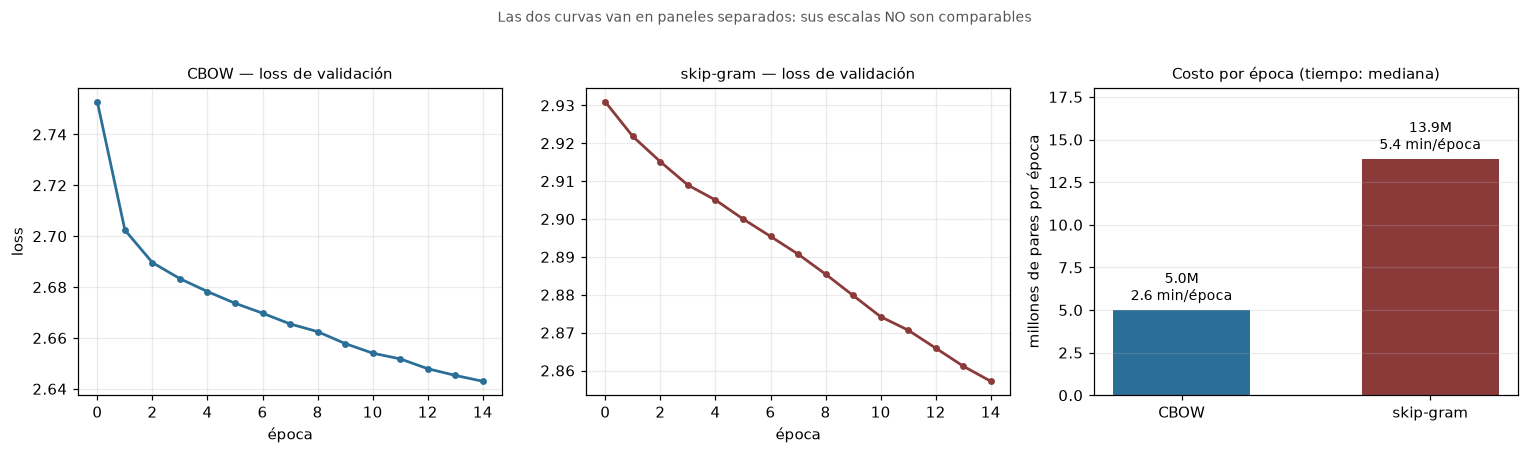

pares  : 2.77x
tiempo : 2.09x
total  : 39 min (CBOW) vs 81 min (skip-gram)   [15 x mediana, descontando las suspensiones]


In [2]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.0))

# --- (a) y (b) curvas de validación, UNA POR PANEL: no se superponen a propósito
for ax, nombre in zip(axes[:2], PAR):
    h = FILAS[nombre]["history"]
    ax.plot([r["epoch"] for r in h], [r["val_loss"] for r in h],
            color=COLOR[nombre], marker="o", ms=3.5, lw=1.8)
    ax.set_title(f"{ETIQUETA[nombre]} — loss de validación", fontsize=10)
    ax.set_xlabel("época")
    ax.grid(alpha=0.25)
axes[0].set_ylabel("loss")

# --- (c) costo por época ----------------------------------------------------
ax = axes[2]
x = np.arange(2)
pares = [FILAS[n]["pairs_per_epoch"] / 1e6 for n in PAR]
barras = ax.bar(x, pares, color=[COLOR[n] for n in PAR], width=0.55)
ax.set_xticks(x, [ETIQUETA[n] for n in PAR])
ax.set_ylabel("millones de pares por época")
ax.set_title("Costo por época (tiempo: mediana)", fontsize=10)
for b, n in zip(barras, PAR):
    minutos = FILAS[n]["seconds_per_epoch_median"] / 60
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.3,
            f"{b.get_height():.1f}M\n{minutos:.1f} min/época",
            ha="center", va="bottom", fontsize=9)
ax.set_ylim(0, max(pares) * 1.30)
ax.grid(axis="y", alpha=0.25)

fig.suptitle("Las dos curvas van en paneles separados: sus escalas NO son comparables",
             fontsize=9, y=1.02, color="#555")
fig.tight_layout()
plt.show()

f_cbow, f_sg = FILAS[CBOW], FILAS[SG]
print(f"pares  : {f_sg['pairs_per_epoch'] / f_cbow['pairs_per_epoch']:.2f}x")
print(f"tiempo : {f_sg['seconds_per_epoch_median'] / f_cbow['seconds_per_epoch_median']:.2f}x")
print(f"total  : {f_cbow['seconds_per_epoch_median']*len(f_cbow['history'])/60:.0f} min (CBOW) "
      f"vs {f_sg['seconds_per_epoch_median']*len(f_sg['history'])/60:.0f} min (skip-gram)"
      "   [15 x mediana, descontando las suspensiones]")

---

## 8.2 Analogías: la comparación que sí vale

Los mismos ítems para las dos corridas. Primero los dos porcentajes con su
intervalo; después la prueba pareada, que es la que decide.

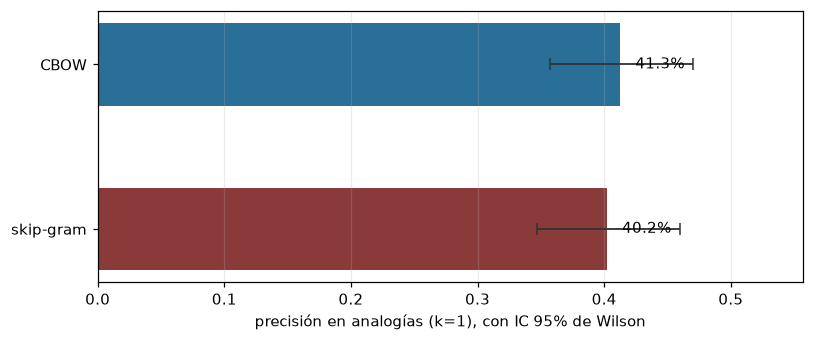

diferencia : -1.0 puntos porcentuales (skip-gram - CBOW)
McNemar    : {'solo_a': 19, 'solo_b': 16, 'ambos': 99, 'ninguno': 152, 'n_desacuerdos': 35, 'p_value': 0.7358788008568808}


In [3]:
fig, ax = plt.subplots(figsize=(7.5, 3.2))

for i, nombre in enumerate(PAR):
    f = FILAS[nombre]
    lo, hi = f["accuracy_ci"]
    ax.barh(i, f["accuracy"], color=COLOR[nombre], height=0.5)
    ax.errorbar(f["accuracy"], i, xerr=[[f["accuracy"] - lo], [hi - f["accuracy"]]],
                fmt="none", ecolor="#333", capsize=4, lw=1.2)
    ax.text(f["accuracy"] + 0.012, i, f"{f['accuracy']:.1%}", va="center", fontsize=10)

ax.set_yticks(range(2), [ETIQUETA[n] for n in PAR])
ax.set_xlabel("precisión en analogías (k=1), con IC 95% de Wilson")
ax.set_xlim(0, max(FILAS[n]["accuracy"] for n in PAR) * 1.35)
ax.grid(axis="x", alpha=0.25)
ax.invert_yaxis()
fig.tight_layout()
plt.show()

prueba = mcnemar(aciertos(CBOW), aciertos(SG))
delta = (FILAS[SG]["accuracy"] - FILAS[CBOW]["accuracy"]) * 100
print(f"diferencia : {delta:+.1f} puntos porcentuales (skip-gram - CBOW)")
print(f"McNemar    : {prueba}")

---

## 8.3 Por categoría

El promedio global puede tapar efectos opuestos. La Fase 7 ya había mostrado que
`plural` es la categoría más débil de CBOW (27,8% con dim 50), así que es el
lugar natural donde buscar una diferencia.

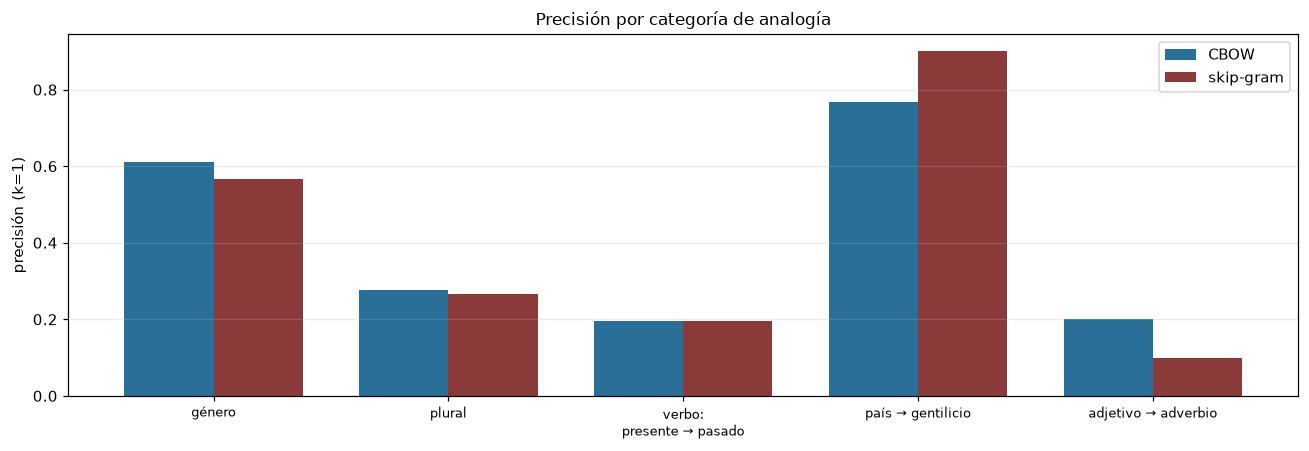

categoría                        CBOW  skip-gram  delta pp  p (McNemar)     n
------------------------------------------------------------------------------
género                         61.1%      56.7%      -4.4       0.3438    90
plural                         27.8%      26.7%      -1.1       1.0000    90
verbo: presente → pasado       19.6%      19.6%      +0.0       1.0000    56
país → gentilicio              76.7%      90.0%     +13.3       0.1250    30
adjetivo → adverbio            20.0%      10.0%     -10.0       0.5000    20


In [4]:
fig, ax = plt.subplots(figsize=(12, 4.2))

ancho = 0.38
x = np.arange(len(CATEGORIAS))
for i, nombre in enumerate(PAR):
    cats = FILAS[nombre]["categories"]
    valores = [cats[c]["accuracy"] for c in CATEGORIAS]
    ax.bar(x + (i - 0.5) * ancho, valores, ancho,
           label=ETIQUETA[nombre], color=COLOR[nombre])

ax.set_xticks(x, [c.replace(": ", ":\n") for c in CATEGORIAS], fontsize=8.5)
ax.set_ylabel("precisión (k=1)")
ax.set_title("Precisión por categoría de analogía", fontsize=11)
ax.legend()
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
plt.show()

print(f"{'categoría':<28} {'CBOW':>8} {'skip-gram':>10} {'delta pp':>9} {'p (McNemar)':>12} {'n':>5}")
print("-" * 78)
for c in CATEGORIAS:
    a, b = FILAS[CBOW]["categories"][c], FILAS[SG]["categories"][c]
    p = mcnemar(aciertos(CBOW, c), aciertos(SG, c))
    print(f"{c:<28} {a['accuracy']:>7.1%} {b['accuracy']:>10.1%} "
          f"{(b['accuracy']-a['accuracy'])*100:>+9.1f} {p['p_value']:>12.4f} "
          f"{a['evaluated']:>5}")

---

## 8.4 La predicción concreta: ¿gana skip-gram con las palabras poco frecuentes?

Esta es la parte más interesante, porque es una hipótesis con mecanismo y no una
comparación a ciegas.

**El argumento**: en CBOW el vector de una palabra entra al `forward` promediado
con los otros 3 del contexto, así que el gradiente que le toca está diluido. En
skip-gram cada par la pone **sola** del lado de la entrada. La palabra que más
sufre esa dilución es la que aparece pocas veces, porque tiene menos
oportunidades de compensarla.

**La medición**: el vocabulario está ordenado por frecuencia, así que el índice
de una palabra *es* su rango. Agrupamos los ítems de analogía según el rango de
la palabra esperada y comparamos las dos arquitecturas dentro de cada grupo.

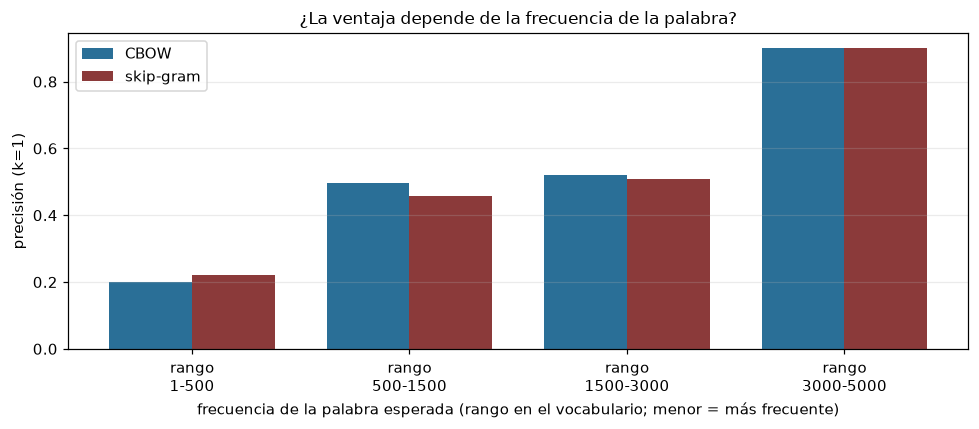

rango              n     CBOW  skip-gram  delta pp  p (McNemar)
----------------------------------------------------------------
1-500            100   20.0%      22.0%      +2.0       0.6875
500-1500         105   49.5%      45.7%      -3.8       0.5235
1500-3000         71   52.1%      50.7%      -1.4       1.0000
3000-5000         10   90.0%      90.0%      +0.0       1.0000


In [5]:
CORTES = [(1, 500), (500, 1500), (1500, 3000), (3000, len(VOCAB))]


def bucket(indice):
    for lo, hi in CORTES:
        if lo <= indice < hi:
            return (lo, hi)
    return CORTES[-1]


# Los ítems son los mismos y en el mismo orden para las dos corridas.
items = FILAS[CBOW]["items"]
hits = {n: aciertos(n) for n in PAR}

grupos = {c: {n: [] for n in PAR} for c in CORTES}
for pos, (cat, a, b, c_, esperada, _) in enumerate(items):
    g = bucket(VOCAB.index(esperada))
    for n in PAR:
        grupos[g][n].append(hits[n][pos])

fig, ax = plt.subplots(figsize=(9, 4.0))
x = np.arange(len(CORTES))
ancho = 0.38
for i, nombre in enumerate(PAR):
    valores = [np.mean(grupos[c][nombre]) if grupos[c][nombre] else np.nan for c in CORTES]
    ax.bar(x + (i - 0.5) * ancho, valores, ancho, label=ETIQUETA[nombre], color=COLOR[nombre])

ax.set_xticks(x, [f"rango\n{lo}-{hi}" for lo, hi in CORTES])
ax.set_xlabel("frecuencia de la palabra esperada (rango en el vocabulario; menor = más frecuente)")
ax.set_ylabel("precisión (k=1)")
ax.set_title("¿La ventaja depende de la frecuencia de la palabra?", fontsize=11)
ax.legend()
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
plt.show()

print(f"{'rango':<14} {'n':>5} {'CBOW':>8} {'skip-gram':>10} {'delta pp':>9} {'p (McNemar)':>12}")
print("-" * 64)
for c in CORTES:
    a, b = grupos[c][CBOW], grupos[c][SG]
    if not a:
        continue
    p = mcnemar(a, b)
    print(f"{f'{c[0]}-{c[1]}':<14} {len(a):>5} {np.mean(a):>7.1%} {np.mean(b):>10.1%} "
          f"{(np.mean(b)-np.mean(a))*100:>+9.1f} {p['p_value']:>12.4f}")

---

## 8.5 Vecinos cercanos, lado a lado

Lo cuantitativo no reemplaza mirar los vectores. Las mismas palabras para las dos
arquitecturas, unas frecuentes y otras no tanto.

In [6]:
EMB = {}
for nombre in PAR:
    EMB[nombre], _ = load_embeddings(load_config(f"configs/{nombre}.yaml"))

CANDIDATAS = ["presidente", "marzo", "rojo", "ciudad",
              "italia", "novela", "orquesta", "kilómetros"]
PALABRAS = [w for w in CANDIDATAS if w in VOCAB]
PALABRAS.sort(key=VOCAB.index)

for w in PALABRAS:
    print(f"\n{w}  (rango {VOCAB.index(w)})")
    for nombre in PAR:
        vecinos = nearest_neighbors(w, EMB[nombre], VOCAB, k=6)
        texto = ", ".join(f"{p} {s:.2f}" for p, s in vecinos)
        print(f"  {ETIQUETA[nombre]:<10} {texto}")


ciudad  (rango 134)
  CBOW       villa 0.77, barrio 0.76, colonia 0.73, plaza 0.72, provincia 0.72, ubicada 0.69
  skip-gram  barrio 0.80, villa 0.78, plaza 0.76, colonia 0.75, córdoba 0.74, provincia 0.73

presidente  (rango 157)
  CBOW       presidenta 0.85, vicepresidente 0.83, presidencia 0.79, embajador 0.74, comisario 0.74, señor 0.73
  skip-gram  vicepresidente 0.85, presidenta 0.84, presidencia 0.77, embajador 0.76, sr 0.74, comisario 0.74

marzo  (rango 348)
  CBOW       abril 0.98, febrero 0.98, julio 0.97, octubre 0.97, mayo 0.97, junio 0.97
  skip-gram  abril 0.97, febrero 0.97, julio 0.96, diciembre 0.95, octubre 0.95, enero 0.95

italia  (rango 1000)
  CBOW       francia 0.91, bélgica 0.90, polonia 0.85, grecia 0.85, alemania 0.83, austria 0.80
  skip-gram  francia 0.91, grecia 0.86, polonia 0.86, alemania 0.84, finlandia 0.82, irlanda 0.81

novela  (rango 1947)
  CBOW       cuento 0.80, protagonista 0.79, película 0.76, comedia 0.75, ficción 0.75, historia 0.75
  skip-g

---

## 8.6 Qué dice el experimento

**Skip-gram no le ganó a CBOW.** 40,2% contra 41,3% en analogías: una diferencia
de −1,0 punto que McNemar deja en **p = 0,74**. De los 286 ítems, 251 los
responden igual (99 bien los dos, 152 mal los dos) y solo discrepan en 35 —19 a
favor de CBOW, 16 a favor de skip-gram. Es el reparto que uno esperaría de tirar
una moneda: un empate estadístico, no una ventaja chica.

Por categoría no se salva ninguna: la mayor diferencia es `país → gentilicio`
(+13,3 pp a favor de skip-gram) y aun así llega apenas a p = 0,125 sobre 30
ítems. `plural`, que era la apuesta más clara —la categoría más débil de CBOW—,
se queda en −1,1 pp con p = 1,00.

Y el costo sí es real: **2,77x más pares y 2,09x más tiempo** (81 min contra 39,
descontando las suspensiones de la máquina). Con esta configuración, la decisión
práctica es CBOW: cuesta la mitad y entrega lo mismo.

### La hipótesis de las palabras poco frecuentes no se pudo probar

El experimento del 8.4 no muestra ninguna ventaja de skip-gram en ningún rango de
frecuencia (+2,0 / −3,8 / −1,4 / +0,0 pp, todos con p ≥ 0,52). Pero la lectura
correcta no es "la hipótesis es falsa" sino **"este experimento no podía
probarla"**, y por una razón concreta:

| | palabra | ocurrencias en el corpus |
|---|---|---|
| rango 1 | `de` | 151.730.127 |
| rango 1000 | `italia` | 197.551 |
| rango 4999 (la última) | `cercana` | **33.838** |

Con un vocabulario de 5.000 palabras sobre 2.028 millones de tokens, **no hay
palabras raras**. La menos frecuente de todas aparece 33.838 veces en el corpus
completo, y unas 707 veces incluso en la muestra del 2% con la que entrenamos. El
mecanismo por el que skip-gram debería ganar —que el gradiente de una palabra no
quede diluido en el promedio de su contexto— necesita palabras que se vean pocas
veces. Acá no las hay: hasta la última del vocabulario tiene cientos de
oportunidades de aprender su vector.

Dicho de otro modo: no medimos que la hipótesis sea falsa, medimos que **el
régimen donde aplica queda fuera de esta configuración**.

> **Cuidado al leer el gráfico del 8.4 de izquierda a derecha.** Los niveles entre
> rangos *no* son comparables, porque los rangos mezclan categorías en
> proporciones muy distintas: el rango 1-500 es 54% `plural` y 28% verbos (las dos
> categorías más difíciles), y el rango 3000-5000 es 100% `país → gentilicio` (la
> más fácil). Por eso las palabras "más frecuentes" parecen las más difíciles: no
> es la frecuencia, es qué se les pregunta. Lo que sí es válido es la comparación
> **dentro** de cada rango, que es pareada sobre los mismos ítems — y ahí no hay
> diferencia.

### Lo que sí se ve, aunque no lo mida la precisión

En los vecinos cercanos (8.5) hay un patrón que las analogías no capturan:
skip-gram produce vecindarios **más apretados** para las palabras menos
frecuentes. `orquesta` (rango 3356) pasa de 0,78 a 0,85 con su vecino más
cercano; `novela` (rango 1947), de 0,80 a 0,85. En las palabras frecuentes
(`marzo`, `presidente`) la diferencia desaparece o se invierte. Es la única señal
compatible con la hipótesis en todo el experimento, y es cualitativa: mayor
coseno no es lo mismo que mejor vecino.

### Cuatro razones por las que este resultado no cierra la pregunta

1. **El vocabulario de 5.000 no tiene cola.** Es la razón principal, la de la
   tabla de arriba. Una prueba real necesita vocabulario 20k+ sobre el corpus
   completo, donde las últimas palabras aparecen cientos de veces y no cientos de
   miles.
2. **El subsampling aplana lo poco que queda.** Con umbral 1e-5, las palabras muy
   frecuentes se descartan casi siempre, lo que acerca artificialmente las
   frecuencias efectivas de todo el vocabulario y borra parte de la asimetría que
   el experimento quería medir.
3. **La ventana es fija.** El word2vec original sortea el tamaño de la ventana por
   token, lo que pondera más a los vecinos cercanos. Se dejó fija a propósito para
   que la comparación aislara la arquitectura, pero es una de las cosas de las que
   skip-gram se beneficia en las implementaciones de referencia.
4. **15 épocas sobre el 2% del corpus.** Skip-gram ve 2,77x más pares por época,
   pero también tiene más que aprender por época; no se probó si la brecha cambia
   con más entrenamiento.

### Lo que queda para la tesis

El resultado publicable es el negativo, y es más útil de lo que parece: **en el
régimen de vocabulario chico y corpus mediano, la arquitectura no importa y la
dimensión sí.** La Fase 7 había medido +12,9 puntos por duplicar la dimensión, con
p < 0,0001. Esta fase mide −1,0 punto por cambiar de arquitectura, con p = 0,74.
Puestos a gastar cómputo, el orden de prioridades quedó medido: primero
dimensión, después vocabulario, y la arquitectura al final.